# CreditFair — Week 1 Analysis Notebook

**Project goal:** Build a responsible-AI credit scoring system that predicts whether a loan applicant is a **good** or **bad** credit risk, with data quality, fairness, transparency, governance, and regulatory compliance.

**Dataset:** *Statlog (German Credit Data)* — Hofmann, 1994, UCI ML Repository. **1,000 applicants, 20 attributes**, binary target (1 = good, 2 = bad), with an official 5:1 cost matrix. File: `german.data` (space-separated, coded `A**` values which this notebook decodes).


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_FILE = "german.data"   # keep this file in the same folder as the notebook


## 2. Load and decode the dataset

The raw `german.data` file is space-separated with **no header** and uses coded categorical values (e.g. `A11`, `A34`). We attach the official column names, decode the `A**` codes into readable words, derive a clean `sex` column, and map the target to `good` / `bad`.

In [2]:
COLS = ["checking_status","duration_months","credit_history","purpose","credit_amount_DM",
        "savings","employment_since","installment_rate_pct","personal_status_sex","other_debtors",
        "residence_since_yrs","property","age_years","other_installment_plans","housing",
        "existing_credits","job","people_liable","telephone","foreign_worker","risk"]

DECODE = {
 "checking_status": {"A11":"<0 DM","A12":"0-200 DM","A13":">=200 DM","A14":"no account"},
 "credit_history": {"A30":"no credits/all paid","A31":"all paid this bank","A32":"paid till now",
                    "A33":"past delay","A34":"critical/other credits"},
 "purpose": {"A40":"car (new)","A41":"car (used)","A42":"furniture/equipment","A43":"radio/TV",
             "A44":"domestic appliances","A45":"repairs","A46":"education","A47":"vacation",
             "A48":"retraining","A49":"business","A410":"others"},
 "savings": {"A61":"<100 DM","A62":"100-500 DM","A63":"500-1000 DM","A64":">=1000 DM","A65":"unknown/none"},
 "employment_since": {"A71":"unemployed","A72":"<1 yr","A73":"1-4 yrs","A74":"4-7 yrs","A75":">=7 yrs"},
 "personal_status_sex": {"A91":"male: div/sep","A92":"female: div/sep/married","A93":"male: single",
                         "A94":"male: married/widowed","A95":"female: single"},
 "other_debtors": {"A101":"none","A102":"co-applicant","A103":"guarantor"},
 "property": {"A121":"real estate","A122":"life insurance","A123":"car/other","A124":"unknown/none"},
 "other_installment_plans": {"A141":"bank","A142":"stores","A143":"none"},
 "housing": {"A151":"rent","A152":"own","A153":"for free"},
 "job": {"A171":"unemployed/unskilled non-res","A172":"unskilled resident","A173":"skilled","A174":"management/self-emp"},
 "telephone": {"A191":"none","A192":"yes"},
 "foreign_worker": {"A201":"yes","A202":"no"},
}
SEX_MAP = {"A91":"male","A92":"female","A93":"male","A94":"male","A95":"female"}

df = pd.read_csv(DATA_FILE, sep=r"\s+", header=None, names=COLS)
df.insert(9, "sex", df["personal_status_sex"].map(SEX_MAP))
for col, mapping in DECODE.items():
    df[col] = df[col].map(mapping).fillna(df[col])
df["risk"] = df["risk"].map({1: "good", 2: "bad"})
df["bad"] = (df["risk"] == "bad").astype(int)   # 1 = bad (the costly class)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 23)


,checking_status,duration_months,credit_history,purpose,credit_amount_DM,savings,employment_since,installment_rate_pct,personal_status_sex,sex,other_debtors,residence_since_yrs,property,age_years,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,risk,bad
0,<0 DM,6,critical/other credits,radio/TV,1169,unknown/none,>=7 yrs,4,male: single,male,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good,0
1,0-200 DM,48,paid till now,radio/TV,5951,<100 DM,1-4 yrs,2,female: div/sep/married,female,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad,1
2,no account,12,critical/other credits,education,2096,<100 DM,4-7 yrs,2,male: single,male,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good,0
3,<0 DM,42,paid till now,furniture/equipment,7882,<100 DM,4-7 yrs,2,male: single,male,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good,0
4,<0 DM,24,past delay,car (new),4870,<100 DM,1-4 yrs,3,male: single,male,none,4,unknown/none,53,none,for free,2,skilled,2,none,yes,bad,1


## 3. Data quality analysis

In [3]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "unique_values": df.nunique(dropna=False),
}).sort_values("unique_values", ascending=False)
display(quality)
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", int(df.isna().sum().sum()))

,dtype,missing_count,unique_values
credit_amount_DM,int64,0,921
age_years,int64,0,53
duration_months,int64,0,33
purpose,object,0,10
credit_history,object,0,5
savings,object,0,5
employment_since,object,0,5
checking_status,object,0,4
job,object,0,4
existing_credits,int64,0,4


Duplicate rows: 0
Total missing values: 0


,risk,count,percent
0,good,700,70.0
1,bad,300,30.0


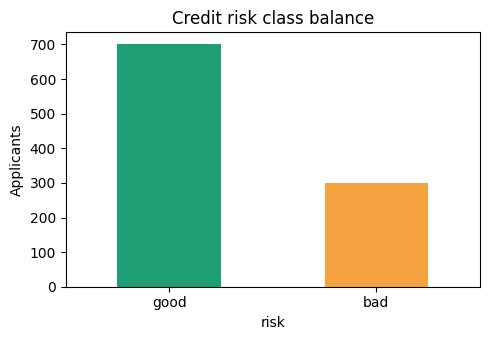

In [4]:
target_summary = df["risk"].value_counts().rename_axis("risk").reset_index(name="count")
target_summary["percent"] = (target_summary["count"] / len(df) * 100).round(1)
display(target_summary)

ax = df["risk"].value_counts().plot(kind="bar", figsize=(5,3.5), color=["#1e9e75","#f4a340"])
ax.set_title("Credit risk class balance"); ax.set_ylabel("Applicants"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

### Data-quality findings
- **1,000 rows, 700 Good / 300 Bad → 30% bad-risk.** Imbalanced but not extreme → accuracy is misleading; use cost / AUC / recall on the bad class.
- **No missing values.** Unlike the reduced version, the full Statlog encoding uses explicit categories such as `no account` and `unknown/none` instead of blanks — so "no checking account" is information, not missingness.
- **Three protected attributes present** (`age_years`, `sex`, `foreign_worker`) → richer fairness analysis than age+sex alone.

## 4. Exploratory data analysis
How features relate to the bad-risk indicator.

In [5]:
numeric_cols = ["age_years","duration_months","credit_amount_DM","installment_rate_pct"]
display(df.groupby("risk")[numeric_cols].mean().round(1))

corr = df[numeric_cols + ["bad"]].corr()["bad"].round(3).sort_values(ascending=False)
print("\nCorrelation of numeric features with bad-risk:")
print(corr)

,age_years,duration_months,credit_amount_DM,installment_rate_pct
risk,,,,
bad,34.0,24.9,3938.1,3.1
good,36.2,19.2,2985.5,2.9



Correlation of numeric features with bad-risk:
bad                     1.000
duration_months         0.215
credit_amount_DM        0.155
installment_rate_pct    0.072
age_years              -0.091
Name: bad, dtype: float64


In [6]:
# strongest categorical predictors: bad-rate by category
def bad_rate(col):
    return (df.groupby(col)["bad"].mean().mul(100).round(1).sort_values(ascending=False))

for col in ["checking_status","credit_history","savings"]:
    print(f"\nBad-risk rate (%) by {col}:")
    print(bad_rate(col))


Bad-risk rate (%) by checking_status:
checking_status
<0 DM         49.3
0-200 DM      39.0
>=200 DM      22.2
no account    11.7
Name: bad, dtype: float64

Bad-risk rate (%) by credit_history:
credit_history
no credits/all paid       62.5
all paid this bank        57.1
paid till now             31.9
past delay                31.8
critical/other credits    17.1
Name: bad, dtype: float64

Bad-risk rate (%) by savings:
savings
<100 DM         36.0
100-500 DM      33.0
500-1000 DM     17.5
unknown/none    17.5
>=1000 DM       12.5
Name: bad, dtype: float64


### EDA interpretation
- **Loan `duration` is the strongest numeric driver** of bad risk (positive correlation), then `credit_amount`; older applicants are slightly lower-risk.
- **`checking_status` is the single strongest predictor:** applicants with a negative balance (`<0 DM`) are bad-risk ~49% of the time, vs only ~12% for those with `no account`.
- **`credit_history` has a well-known counter-intuitive pattern:** "critical/other credits" applicants are *lower* risk (~17%) while "no credits / all paid" look *higher* risk (~63%) — having a track record helps. Worth flagging in the model interpretation.

## 5. Fairness analysis (Age, Sex, Foreign worker)
Base-rate disparities in the historical labels — the gaps our model must not amplify.

In [7]:
df["age_group"] = pd.cut(df["age_years"], [18,25,35,50,120], labels=["18-25","26-35","36-50","50+"])

for col in ["sex","age_group","foreign_worker"]:
    print(f"Bad-risk rate by {col}:")
    print((df.groupby(col, observed=True)["bad"].mean().mul(100).round(1)).to_string())
    print()

print("foreign_worker group sizes:", df["foreign_worker"].value_counts().to_dict())

Bad-risk rate by sex:
sex
female    35.2
male      27.7

Bad-risk rate by age_group:
age_group
18-25    42.1
26-35    29.6
36-50    23.7
50+      27.4

Bad-risk rate by foreign_worker:
foreign_worker
no     10.8
yes    30.7

foreign_worker group sizes: {'yes': 963, 'no': 37}


In [8]:
# Four-fifths / Disparate Impact check (approval = predicted/observed 'good')
def disparate_impact(col):
    good_rate = df.groupby(col, observed=True).apply(lambda g: (g["risk"]=="good").mean())
    di = good_rate / good_rate.max()
    return good_rate.round(3), di.round(3)

for col in ["sex","foreign_worker"]:
    gr, di = disparate_impact(col)
    print(f"\n{col}: good(approval)-rate\n{gr.to_string()}\nDisparate Impact vs best group (>=0.80 passes):\n{di.to_string()}")


sex: good(approval)-rate
sex
female    0.648
male      0.723
Disparate Impact vs best group (>=0.80 passes):
sex
female    0.897
male      1.000

foreign_worker: good(approval)-rate
foreign_worker
no     0.892
yes    0.693
Disparate Impact vs best group (>=0.80 passes):
foreign_worker
no     1.000
yes    0.777


/sessions/optimistic-magical-ptolemy/tmp/ipykernel_10/4060734598.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  good_rate = df.groupby(col, observed=True).apply(lambda g: (g["risk"]=="good").mean())
/sessions/optimistic-magical-ptolemy/tmp/ipykernel_10/4060734598.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  good_rate = df.groupby(col, observed=True).apply(lambda g: (g["risk"]=="good").mean())


### Fairness findings
- **Sex:** women are labelled bad-risk **35%** vs men **28%**.
- **Age:** youngest applicants (18-25) **42%** vs 36-50 **24%** — the widest age gap.
- **Foreign worker:** **31%** bad vs **11%** for non-foreign — a large gap, *but* only **37** applicants are non-foreign, so this estimate is fragile (representativeness caveat).
- These are the historical biases the model would inherit; Week 2 mitigation targets them.

## 6. Proxy / redlining check
Even after removing a protected attribute, other features can predict it — proxy discrimination.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def proxy_auc(target, drop):
    X = pd.get_dummies(df.drop(columns=[c for c in drop if c in df.columns]), drop_first=True)
    y = (df[target] == df[target].mode()[0]).astype(int)
    return cross_val_score(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
                           X, y, cv=4, scoring="roc_auc").mean()

auc_sex = proxy_auc("sex", ["sex","personal_status_sex","risk","bad","age_group"])
auc_fw  = proxy_auc("foreign_worker", ["foreign_worker","risk","bad","age_group"])
print(f"AUC predicting sex from other features:            {auc_sex:.3f}")
print(f"AUC predicting foreign_worker from other features: {auc_fw:.3f}")
print(">> Both well above 0.5 => proxy leakage exists. Dropping the attribute is not enough.")

AUC predicting sex from other features:            0.722
AUC predicting foreign_worker from other features: 0.820
>> Both well above 0.5 => proxy leakage exists. Dropping the attribute is not enough.


## 7. The cost matrix
The Statlog task defines an **asymmetric cost**: classifying a **bad** customer as **good** costs **5x** more than the reverse.

|            | Predicted good | Predicted bad |
|------------|:-:|:-:|
| **Actually good** | 0 | 1 |
| **Actually bad**  | **5** | 0 |

In [10]:
COST = {"fp_good_as_bad": 1, "fn_bad_as_good": 5}
def total_cost(y_true_bad, y_pred_bad):
    fp = int(((y_pred_bad==1) & (y_true_bad==0)).sum())  # good flagged bad -> 1
    fn = int(((y_pred_bad==0) & (y_true_bad==1)).sum())  # bad approved     -> 5
    return fp*COST["fp_good_as_bad"] + fn*COST["fn_bad_as_good"]
print("Cost helper ready — use this instead of accuracy in Week 2.")

Cost helper ready — use this instead of accuracy in Week 2.


## **Week 1 conclusions**
We have the authentic **1,000-row Statlog** dataset (decoded, no missing values), quantified fairness gaps across **age, sex, and foreign-worker**, confirmed **proxy leakage**, adopted the **5:1 cost matrix**, and set a defensible plan, architecture, and regulatory map. **Next (Week 2):** build the baseline + gradient-boosting models with cost-sensitive validation, apply pre-processing fairness mitigation, and produce the fairness-accuracy trade-off.